# Sprint 11 - Proyecto

Felicidades! Has completado el curso La toma de decisiones de negocios basadas en datos. Es hora de aplicar el conocimiento y las habilidades que has adquirido en un proyecto: un estudio de caso analítico real que completarás por tu cuenta.

Cuando finalices el proyecto, envía tu trabajo al revisor de proyecto para su evaluación. Te dará su opinión en 24 horas. Utiliza los comentarios para realizar cambios y luego envía la nueva versión al revisor.

Es posible que recibas más comentarios sobre esta nueva versión. Esto es totalmente normal. No es nada raro que pases por varios ciclos de comentarios y revisiones.

Tu proyecto se considerará completado una vez que el revisor del proyecto lo apruebe.

Vamos a ver el proyecto final del curso.

## Descripción del proyecto

#### Contexto

Eres analista en una gran tienda online. Junto con el departamento de marketing has recopilado una lista de hipótesis que pueden ayudar a aumentar los ingresos.

Tienes que priorizar estas hipótesis, lanzar un test A/B y analizar los resultados.

## Descripción de los datos

#### Datos utilizados en la primera parte del proyecto

> /datasets/hypotheses_us.csv

* Hypotheses: breves descripciones de las hipótesis.
* Reach: alcance del usuario, en una escala del uno a diez.
* Impact: impacto en los usuarios, en una escala del uno al diez.
* Confidence: confianza en la hipótesis, en una escala del uno al diez.
* Effort: los recursos necesarios para probar una hipótesis, en una escala del uno al diez. Cuanto mayor sea el valor Effort, más recursos requiere la prueba.

#### Datos utilizados en la segunda parte del proyecto

> /datasets/orders_us.csv

* transactionId: identificador de pedido.
* visitorId: identificador del usuario que realizó el pedido.
* date: fecha del pedido.
* revenue: ingresos del pedido.
* group: el grupo del test A/B al que pertenece el usuario.

> /datasets/visits_us.csv

* date: la fecha.
* group: grupo de la prueba A/B.
* visits: el número de visitas en la fecha especificada en el grupo de pruebas A/B especificado.

Asegúrate de preprocesar los datos. Es posible que haya errores en los datasets originales; por ejemplo, algunos de los visitantes podrían haber entrado tanto en el grupo A como en el grupo B.

### Parte 1. Priorizar hipótesis

El archivo hypotheses_us.csv contiene nueve hipótesis sobre cómo aumentar los ingresos de una tienda online con Reach, Impact, Confidence y Effort especificados para cada una.

El ejercicio consiste en:

* Aplicar el framework ICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.
* Aplicar el framework RICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.
* Mostrar cómo cambia la priorización de hipótesis cuando utilizas RICE en lugar de ICE. Proporcionar una explicación de los cambios.

### Parte 2. Análisis del test A/B

Realizaste una prueba A/B y obtuviste los resultados descritos en los archivos orders_us.csv y visits_us.csv.

#### Ejercicio

Analiza el test A/B:

1. Representa gráficamente el ingreso acumulado por grupo. Haz conclusiones y conjeturas.
2. Representa gráficamente el tamaño de pedido promedio acumulado por grupo. Haz conclusiones y conjeturas.
3. Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A. Haz conclusiones y conjeturas.
4. Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. Saca conclusiones y haz conjeturas.
5. Traza un gráfico de dispersión del número de pedidos por usuario. Haz conclusiones y conjeturas.
6. Calcula los percentiles 95 y 99 del número de pedidos por usuario. Define el punto en el cual un punto de datos se convierte en una anomalía.
7. Traza un gráfico de dispersión de los precios de los pedidos. Haz conclusiones y conjeturas.
8. Calcula los percentiles 95 y 99 de los precios de los pedidos. Define el punto en el cual un punto de datos se convierte en una anomalía.
9. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.
10. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.
11. Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.
12. Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.
13. Toma una decisión basada en los resultados de la prueba. Las decisiones posibles son: 1. Parar la prueba, considerar a uno de los grupos como líder. 2. Parar la prueba, concluir que no hay diferencia entre los grupos. 3. Continuar la prueba.


# 1.0 Importación de datos y librerias

[Se procede a importar las librerias]

In [5]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px
from functools import reduce
import scipy.stats as stats
import datetime as dt

[Se procede a importar los datos]

In [6]:
# Se cargan los datos para Notebook Jupiter de Tripleten

# hypotheses = pd.read_csv('/datasets/hypotheses_us.csv')
# orders = pd.read_csv('/datasets/orders_us.csv')
# visits = pd.read_csv('/datasets/visits_us.csv')

# Se cargan los datos para trabajar en Notebook

hypotheses = pd.read_csv('DF/hypotheses_us.csv')
orders = pd.read_csv('DF/orders_us.csv')
visits = pd.read_csv('DF/visits_us.csv')

# 2.0 Preparación de los datos

[Se procede a realizar un análisis exploratorio de los datos para corroborar el contenido y en caso de ser necesario, ordenar y depurar los mismos.]

## 2.1 Visualización inicial de los datos

[Se visualizara cada DF, limpiara y ordenara segun los datos correspondientes de manera individual:]

### 2.1.1 Visualización y limpieza del DF "hypothesses"

[Se visualiza la información del DF en cuestión]

In [7]:
# Se procede a visualizar la información y el contenido de las primeras 10 lineas del DF "hypothesses"

hypotheses.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
hypotheses.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 1 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Hypothesis;Reach;Impact;Confidence;Effort  9 non-null      object
dtypes: object(1)
memory usage: 204.0+ bytes
 
 
---------------------------------------
 
 


,Hypothesis;Reach;Impact;Confidence;Effort
0,Add two new channels for attracting traffic. T...
1,Launch your own delivery service. This will sh...
2,Add product recommendation blocks to the store...
3,Change the category structure. This will incre...
4,Change the background color on the main page. ...
5,Add a customer review page. This will increase...
6,Show banners with current offers and sales on ...
7,Add a subscription form to all the main pages....
8,Launch a promotion that gives users discounts ...


#### 2.1.1.1 Ordenamiento de datos

[Se procede a ordenar los datos para volverlos entendibles]

In [8]:
# Se mete separación en el data frame original

hypotheses = pd.read_csv('DF/hypotheses_us.csv', sep = ';')

# Se verifica que se haya gnerado la separación de manera correcta:

hypotheses.head(10)


,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


In [9]:
# Se convierten las columnas a minusculas

hypotheses.columns = hypotheses.columns.str.lower()

# Se convierte el contenido de la columna 'hypothesis' a minuscula

hypotheses['hypothesis'] = hypotheses['hypothesis'].str.lower()

# Se verifica que se haya generado el cambio de manera correcta

hypotheses.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
hypotheses.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   hypothesis  9 non-null      object
 1   reach       9 non-null      int64 
 2   impact      9 non-null      int64 
 3   confidence  9 non-null      int64 
 4   effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes
 
 
---------------------------------------
 
 


,hypothesis,reach,impact,confidence,effort
0,add two new channels for attracting traffic. t...,3,10,8,6
1,launch your own delivery service. this will sh...,2,5,4,10
2,add product recommendation blocks to the store...,8,3,7,3
3,change the category structure. this will incre...,8,3,3,8
4,change the background color on the main page. ...,3,1,1,1
5,add a customer review page. this will increase...,3,2,2,3
6,show banners with current offers and sales on ...,5,3,8,3
7,add a subscription form to all the main pages....,10,7,8,5
8,launch a promotion that gives users discounts ...,1,9,9,5


### 2.1.2 Visualización y limpieza del DF "orders"

[Se visualiza la información del DF en cuestión]

In [10]:
# Se procede a visualizar la información y el contenido de las primeras 10 lineas del DF "orders"

orders.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
orders.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB
 
 
---------------------------------------
 
 


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B
6,398296753,2900797465,2019-08-15,30.6,B
7,2626614568,78758296,2019-08-15,20.1,A
8,1576988021,295230930,2019-08-15,215.9,A
9,1506739906,1882260405,2019-08-15,30.5,B


#### 2.1.2.1 Ordenamiento de datos

[Se procede a ordenar los datos, verificando que no haya datos duplicados y corrigiendo errores en la ubicacion erronea de algunas ordenes de los visitantes ya que podrían haber entrado tanto en el grupo A como en el grupo B]

In [11]:
# Se verifica la duplicidad de los datos

print('La cantidad de datos duplicados es:', orders.duplicated().sum())

# Se verifica la duplicidad de las ordenes de los visitantes

grouped_visitors = orders.groupby('visitorId')['group'].nunique()
double_grouped_visitors = grouped_visitors[grouped_visitors > 1]
double_grouped_visitors_count = len(double_grouped_visitors)

print(f"Número de visitantes que están en ambos grupos: {double_grouped_visitors_count}")
if double_grouped_visitors_count > 0:
    print("IDs de visitantes que están en ambos grupos:")
    display(double_grouped_visitors.index.tolist())

La cantidad de datos duplicados es: 0
Número de visitantes que están en ambos grupos: 58
IDs de visitantes que están en ambos grupos:


[8300375,
 199603092,
 232979603,
 237748145,
 276558944,
 351125977,
 393266494,
 457167155,
 471551937,
 477780734,
 818047933,
 963407295,
 1230306981,
 1294878855,
 1316129916,
 1333886533,
 1404934699,
 1602967004,
 1614305549,
 1648269707,
 1668030113,
 1738359350,
 1801183820,
 1959144690,
 2038680547,
 2044997962,
 2378935119,
 2458001652,
 2579882178,
 2587333274,
 2600415354,
 2654030115,
 2686716486,
 2712142231,
 2716752286,
 2780786433,
 2927087541,
 2949041841,
 2954449915,
 3062433592,
 3202540741,
 3234906277,
 3656415546,
 3717692402,
 3766097110,
 3803269165,
 3891541246,
 3941795274,
 3951559397,
 3957174400,
 3963646447,
 3972127743,
 3984495233,
 4069496402,
 4120364173,
 4186807279,
 4256040402,
 4266935830]

[Para la limpiar los datos, se elimina los visitantes de ambos grupos para asegurar la validez de los tests A/B que se estaran realizando mas adelante]

In [12]:
# Filtrar los pedidos para eliminar a los visitantes que están en ambos grupos
orders_filtered = orders[~orders['visitorId'].isin(double_grouped_visitors.index)]

print(f"Número de entradas después de filtrar visitantes que estaban en ambos grupos: {orders_filtered.shape[0]}")

Número de entradas después de filtrar visitantes que estaban en ambos grupos: 1016


[Por ultimo, se procede a converitr las columnas del DF filtrado en el tipo correcto]

In [13]:
# Se convierten las columnas 'transactionId' y 'visitorId' del DF "orders_filtered" en "object"

orders_filtered['transactionId'] = orders_filtered['transactionId'].astype('object')
orders_filtered['visitorId'] = orders_filtered['visitorId'].astype('object')

# Se convirte la columna 'date' en "datetime"

orders_filtered['date'] = pd.to_datetime(orders_filtered['date'])

# Se verifica que el DF este correcto con los tipos de columnas correctos

orders_filtered.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
orders_filtered.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1016 non-null   object        
 1   visitorId      1016 non-null   object        
 2   date           1016 non-null   datetime64[ns]
 3   revenue        1016 non-null   float64       
 4   group          1016 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 47.6+ KB
 
 
---------------------------------------
 
 


/tmp/ipykernel_100149/396055767.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_filtered['transactionId'] = orders_filtered['transactionId'].astype('object')
/tmp/ipykernel_100149/396055767.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orders_filtered['visitorId'] = orders_filtered['visitorId'].astype('object')
/tmp/ipykernel_100149/396055767.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value inst

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B
6,398296753,2900797465,2019-08-15,30.6,B
7,2626614568,78758296,2019-08-15,20.1,A
8,1576988021,295230930,2019-08-15,215.9,A
9,1506739906,1882260405,2019-08-15,30.5,B
10,3649131742,879864040,2019-08-15,65.7,A


### 2.1.3 Visualización y limpieza del DF "visits"

[Se visualiza la información del DF en cuestión]

In [14]:
# Se procede a visualizar la información y el contenido de las primeras 10 lineas del DF "orders"

visits.info()
print(' ')
print(' ')
print('-------------------------------------')
print(' ')
print(' ')
visits.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB
 
 
-------------------------------------
 
 


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


#### 2.1.3.1 Ordenamiento de datos

[Se procede a ordenar los datos, verificando que no haya datos duplicados y cambiando los/el tipo de columna según sea necesario]

In [15]:
# Se verifica la duplicidad de los datos

print('La cantidad de datos duplicados es:', visits.duplicated().sum())
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')

# Se cambia el tipo de columna de la columna 'date' por "datetime"

visits['date'] = pd.to_datetime(visits['date'])

# Se verifica que el DF este correcto:

visits.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
visits.head(10)

La cantidad de datos duplicados es: 0
 
 
---------------------------------------
 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[ns]
 1   group   62 non-null     object        
 2   visits  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB
 
 
---------------------------------------
 
 


,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


# 3.0 Parte 1. Priorizar hipótesis

El archivo ***hypotheses_us.csv*** contiene nueve hipótesis sobre cómo aumentar los ingresos de una tienda online con Reach, Impact, Confidence y Effort especificados para cada una.

***El ejercicio consiste en:***

* Aplicar el framework ICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.
* Aplicar el framework RICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.
* Mostrar cómo cambia la priorización de hipótesis cuando utilizas RICE en lugar de ICE. Proporcionar una explicación de los cambios.

## 3.1 Calculo del ICE

[Se procede a realizar el calculo del framwork ICE para posteriormente ordenarlo en orden descendente]

In [16]:
# Se realiza el calculo del ICE creando un nuevo DF a partir del DF "hypotheses" copiando todas la columnas del mismo

hypotheses_ice = hypotheses.copy()

# Se crea una nueva columna en el DF "hypotheses_ice", en esta se procedera a usar la formula de ICE la cual es "('impact' * 'confidence') / 'efforts'"

hypotheses_ice['ice'] = (hypotheses_ice['impact'] * hypotheses_ice['confidence']) / hypotheses_ice['effort']

# Se procede a ordenarlas en orden descendente de prioridad

hypotheses_ice = hypotheses_ice.sort_values(by='ice', ascending=False)

# Se imprime el nuevo DF para la verificación de su contenido:

hypotheses_ice.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
hypotheses_ice.head(10)



<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 8 to 4
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   hypothesis  9 non-null      object 
 1   reach       9 non-null      int64  
 2   impact      9 non-null      int64  
 3   confidence  9 non-null      int64  
 4   effort      9 non-null      int64  
 5   ice         9 non-null      float64
dtypes: float64(1), int64(4), object(1)
memory usage: 504.0+ bytes
 
 
---------------------------------------
 
 


,hypothesis,reach,impact,confidence,effort,ice
8,launch a promotion that gives users discounts ...,1,9,9,5,16.200000
0,add two new channels for attracting traffic. t...,3,10,8,6,13.333333
7,add a subscription form to all the main pages....,10,7,8,5,11.200000
6,show banners with current offers and sales on ...,5,3,8,3,8.000000
2,add product recommendation blocks to the store...,8,3,7,3,7.000000
1,launch your own delivery service. this will sh...,2,5,4,10,2.000000
5,add a customer review page. this will increase...,3,2,2,3,1.333333
3,change the category structure. this will incre...,8,3,3,8,1.125000
4,change the background color on the main page. ...,3,1,1,1,1.000000


In [17]:
# Se procede a imprimir unicamente las columnas 'hypotheses' y 'ice'

print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
print(hypotheses_ice[['hypothesis', 'ice']])

 
 
---------------------------------------
 
 
                                          hypothesis        ice
8  launch a promotion that gives users discounts ...  16.200000
0  add two new channels for attracting traffic. t...  13.333333
7  add a subscription form to all the main pages....  11.200000
6  show banners with current offers and sales on ...   8.000000
2  add product recommendation blocks to the store...   7.000000
1  launch your own delivery service. this will sh...   2.000000
5  add a customer review page. this will increase...   1.333333
3  change the category structure. this will incre...   1.125000
4  change the background color on the main page. ...   1.000000


## 3.2 Calculo del RICE

[Se procede a realizar el calculo del framwork RICE para posteriormente ordenarlo en orden descendente]

In [18]:
# Se realiza el calculo del RICE creando un nuevo DF a partir del DF "hypotheses" copiando todas la columnas del mismo

hypotheses_rice = hypotheses.copy()

# Se crea una nueva columna en el DF "hypotheses_rice", en esta se procede a usar la formula de RICE la cual es "('reach' * 'impact' * 'confidence') / 'efforts'"

hypotheses_rice['rice'] = (hypotheses_rice['reach'] * hypotheses_rice['impact'] * hypotheses_rice['confidence']) / hypotheses_rice['effort']

# Se procede a ordenarlas en orden descendente de prioridad

hypotheses_rice = hypotheses_rice.sort_values(by='rice', ascending=False)

# Se imprime el nuevo DF para la verificación de su contenido:

hypotheses_rice.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
hypotheses_rice.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 9 entries, 7 to 4
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   hypothesis  9 non-null      object 
 1   reach       9 non-null      int64  
 2   impact      9 non-null      int64  
 3   confidence  9 non-null      int64  
 4   effort      9 non-null      int64  
 5   rice        9 non-null      float64
dtypes: float64(1), int64(4), object(1)
memory usage: 504.0+ bytes
 
 
---------------------------------------
 
 


,hypothesis,reach,impact,confidence,effort,rice
7,add a subscription form to all the main pages....,10,7,8,5,112.0
2,add product recommendation blocks to the store...,8,3,7,3,56.0
0,add two new channels for attracting traffic. t...,3,10,8,6,40.0
6,show banners with current offers and sales on ...,5,3,8,3,40.0
8,launch a promotion that gives users discounts ...,1,9,9,5,16.2
3,change the category structure. this will incre...,8,3,3,8,9.0
1,launch your own delivery service. this will sh...,2,5,4,10,4.0
5,add a customer review page. this will increase...,3,2,2,3,4.0
4,change the background color on the main page. ...,3,1,1,1,3.0


In [19]:
# Se procede a imprimir unicamente las columnas 'hypotheses' y 'rice'

print(hypotheses_rice[['hypothesis', 'rice']])

                                          hypothesis   rice
7  add a subscription form to all the main pages....  112.0
2  add product recommendation blocks to the store...   56.0
0  add two new channels for attracting traffic. t...   40.0
6  show banners with current offers and sales on ...   40.0
8  launch a promotion that gives users discounts ...   16.2
3  change the category structure. this will incre...    9.0
1  launch your own delivery service. this will sh...    4.0
5  add a customer review page. this will increase...    4.0
4  change the background color on the main page. ...    3.0


## 3.3 Priorización de hipótesis cuando utilizas RICE en lugar de ICE.

[Mostrar cómo cambia la priorización de hipótesis cuando utilizas RICE en lugar de ICE. Proporcionar una explicación de los cambios.]

Para una mejor visualización, se procedera a mostrar nuevamente el ordenamiento de ICE y RICE.

In [20]:
#Se procede a imprimir "hypotheses_ice"

print('Priorización de Hipotesis mediante el uso de ICE:')
print(hypotheses_ice[['hypothesis', 'ice']])

print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')

#Se procede a imprimir "hypotheses_rice"

print('Priorización de Hipotesis mediante el uso de RICE:')
print(hypotheses_rice[['hypothesis', 'rice']])

Priorización de Hipotesis mediante el uso de ICE:
                                          hypothesis        ice
8  launch a promotion that gives users discounts ...  16.200000
0  add two new channels for attracting traffic. t...  13.333333
7  add a subscription form to all the main pages....  11.200000
6  show banners with current offers and sales on ...   8.000000
2  add product recommendation blocks to the store...   7.000000
1  launch your own delivery service. this will sh...   2.000000
5  add a customer review page. this will increase...   1.333333
3  change the category structure. this will incre...   1.125000
4  change the background color on the main page. ...   1.000000
 
 
---------------------------------------
 
 
Priorización de Hipotesis mediante el uso de RICE:
                                          hypothesis   rice
7  add a subscription form to all the main pages....  112.0
2  add product recommendation blocks to the store...   56.0
0  add two new channels for att

Conclusiones:

* ICE: El framework de ICE toma encuenta el Impacto, Confianza vs el esfuerzo que se requiere para la implementación de una hipótesis. Es util para la evaluación rapida de la viabilidad y potencial de las hipótesis, sin embargo, esta no toma en cuenta el tamaño de la audiencia objetivo.

* RICE: Por otra parte, el framework RICE si toma en cuenta el alcance en su formula para poder efectuar la metrica.

Con lo anterior tomado en cuenta, es importante efectuar los dos frameworks en simultaneo para poder tener un comparativo y una mayor visión al momento de aterrizar una hipótesis. De esta manera se podra obtener con una probabilidad mas positiva un cambio optimo con la menor cantidad de intentos posibles.

Retomando el punto central, como podemos apreciar, el orden de las hipótesis cambia en orden entre el ICE y el RICE ¿A que se debe este cambio? Se debe principalmente al impacto y confianza vs esfuerzo de las hipótesis, si bien, al momento de correo ICE se puede tener una apreciación mas positivas entre unas hipótesis y otras, un factor a tomar en cuenta al momento de decidir cual hipótesis aterrizar es "el alcance de nuestro publico objetivo", es alli donde, si bien, en ICE algunas hipótesis estan mejor puntuadas, en cuanto a alcance no les fue de la misma manera ¿Eso es malo?, no realmente, mas bien es util para poder tener un orden de prioridad mas claro al momento de efectuar las hipótesis y de esta manera obtener una mayor rentabilidad.

Al analizar los datos anteriores, se recomienda dar como prioridad las hipótesis "7, 0 y 6", Ya que fueron las mas equilibradas y se podra tener un beneficio mayor a corto, mediano y largo plazo.

# 4.0 Parte 2. Análisis del test A/B

[Realizaste una prueba A/B y obtuviste los resultados descritos en los archivos orders_us.csv y visits_us.csv.]

Ejercicio:

* Analiza el test A/B:

## 4.1 Ejercicio 1

Instrucción: Representa gráficamente el ingreso acumulado por grupo. Haz conclusiones y conjeturas.

[Se visualiza el DF filtrado con el que se va a trabajar]

In [21]:
# Se visualiza la información y las primeras 10 columnas del DF "orders_filtered"

orders_filtered.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
orders_filtered.head(10)

<class 'pandas.core.frame.DataFrame'>
Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  1016 non-null   object        
 1   visitorId      1016 non-null   object        
 2   date           1016 non-null   datetime64[ns]
 3   revenue        1016 non-null   float64       
 4   group          1016 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 47.6+ KB
 
 
---------------------------------------
 
 


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B
6,398296753,2900797465,2019-08-15,30.6,B
7,2626614568,78758296,2019-08-15,20.1,A
8,1576988021,295230930,2019-08-15,215.9,A
9,1506739906,1882260405,2019-08-15,30.5,B
10,3649131742,879864040,2019-08-15,65.7,A


[Se agrupara en 2 DF diferentes cada uno de los grupos para graficar los ingresos de cada uno]

In [22]:
# Se crea un nuevo DF donde se agrupara todos los integrantes del grupo 'A' conservando todas las columnas de "orders_filtered"

orders_filtered_a = orders_filtered[orders_filtered['group'] == 'A'].reset_index(drop=True)

# Se repite el mismo paso pero ahora con el grupo 'B'

orders_filtered_b = orders_filtered[orders_filtered['group'] == 'B'].reset_index(drop=True)

# Se verifican los datos:

print('Estos son los datos del grupo A:')
orders_filtered_a.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
print(orders_filtered_a.head(10))
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
print('Estos son los datos del grupo B:')
orders_filtered_b.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
print(orders_filtered_b.head(10))

Estos son los datos del grupo A:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 468 entries, 0 to 467
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   transactionId  468 non-null    object        
 1   visitorId      468 non-null    object        
 2   date           468 non-null    datetime64[ns]
 3   revenue        468 non-null    float64       
 4   group          468 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 18.4+ KB
 
 
---------------------------------------
 
 
  transactionId   visitorId       date  revenue group
0    2626614568    78758296 2019-08-15     20.1     A
1    1576988021   295230930 2019-08-15    215.9     A
2    3649131742   879864040 2019-08-15     65.7     A
3    2809384911  3213223594 2019-08-15    115.4     A
4    3859315276  1565034404 2019-08-15    170.9     A
5    1822256754  4227830084 2019-08-15    255.7     A
6     67

[Se grafican los ingresos de cada grupo]

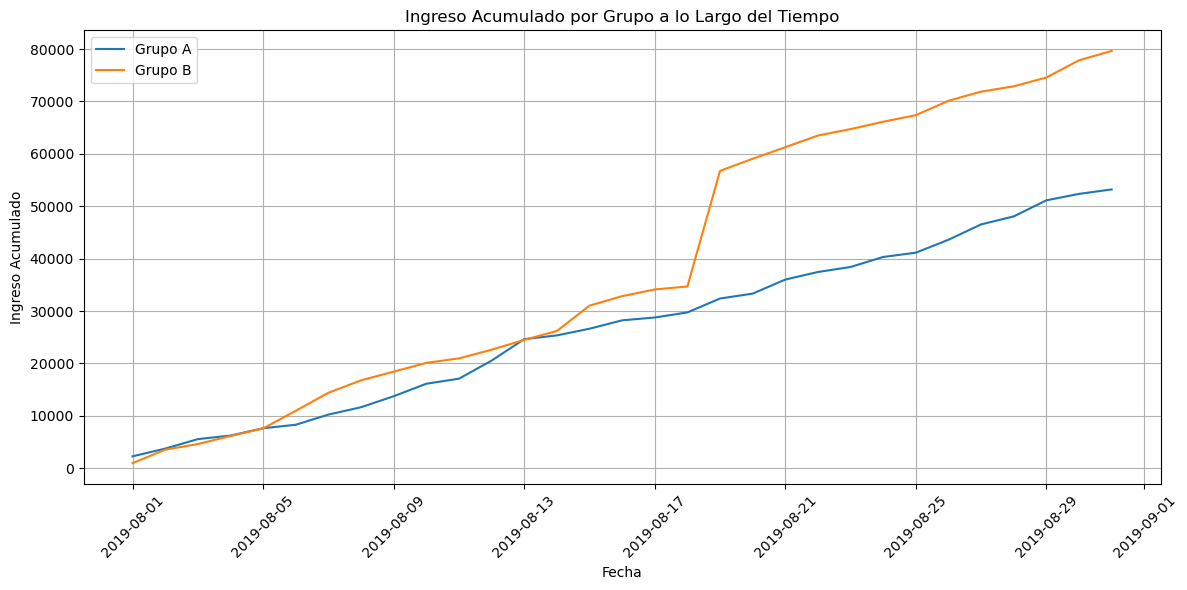

In [23]:
# Se obtienen las fechas únicas y se ordenan
dates = orders_filtered['date'].unique().tolist()
dates.sort()

# Se crea un DataFrame con las fechas únicas y los grupos
cumulative_data = pd.DataFrame({'date': dates})

# Se calcula el número acumulado de pedidos y el ingreso acumulado para el grupo A
cumulative_orders_a = orders_filtered_a.groupby('date').agg({'transactionId': 'nunique', 'revenue': 'sum'}).reset_index()
cumulative_orders_a.columns = ['date', 'orders_a', 'revenue_a']
cumulative_orders_a['orders_cumulative_a'] = cumulative_orders_a['orders_a'].cumsum()
cumulative_orders_a['revenue_cumulative_a'] = cumulative_orders_a['revenue_a'].cumsum()

# Se calcula el número acumulado de pedidos y el ingreso acumulado para el grupo B
cumulative_orders_b = orders_filtered_b.groupby('date').agg({'transactionId': 'nunique', 'revenue': 'sum'}).reset_index()
cumulative_orders_b.columns = ['date', 'orders_b', 'revenue_b']
cumulative_orders_b['orders_cumulative_b'] = cumulative_orders_b['orders_b'].cumsum()
cumulative_orders_b['revenue_cumulative_b'] = cumulative_orders_b['revenue_b'].cumsum()

# Se combinan los datos acumulados
cumulative_data = cumulative_data.merge(cumulative_orders_a[['date', 'revenue_cumulative_a']], on='date', how='left')
cumulative_data = cumulative_data.merge(cumulative_orders_b[['date', 'revenue_cumulative_b']], on='date', how='left')

# Se rellenan los valores nulos con el valor anterior para mantener la acumulación
cumulative_data['revenue_cumulative_a'] = cumulative_data['revenue_cumulative_a'].ffill()
cumulative_data['revenue_cumulative_b'] = cumulative_data['revenue_cumulative_b'].ffill()

# Se eliminan los nulos iniciales si los hubiera (antes del primer registro)
cumulative_data = cumulative_data.fillna(0)

# Se grafica el ingreso acumulado por grupo
plt.figure(figsize=(12, 6))
plt.plot(cumulative_data['date'], cumulative_data['revenue_cumulative_a'], label='Grupo A')
plt.plot(cumulative_data['date'], cumulative_data['revenue_cumulative_b'], label='Grupo B')
plt.title('Ingreso Acumulado por Grupo a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ingreso Acumulado')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.1.1 Conclusiones ejercicio 1:

* Al revisar los ingresos de ambos grupos, en primera instancia podemos apreciar que ambos grupos muestran un crecimiento acumulado y constante.

* En segunda instancia, los ingresos acumulados del grupo "B" superan en creces a los del grupo "A", esto es en cuanto a ingresos acumulados.

* En tercera instancia, al momento de revisar las fechas del periodo entre el 17 y 20 de Agosto del 2019, podemos apreciar que se presento una curvatura anomala en cuanto a los ingresos acumulados, esto podría ser una bandera roja o bien, en esos dias se presentaron pedidos extraordinarios modificando así la tendencia hacia la alza. Este pico podría llegar a alterar los resultados de la prueba.

Se realizara un trabajo de investigación para revisar si existen valores atipicos en los pedidos del Grupo "B" que pudiesen llegara a afectar la prueba.

## 4.2 Ejercicio 2

Instrucción: Representa gráficamente el tamaño de pedido promedio acumulado por grupo. Haz conclusiones y conjeturas.

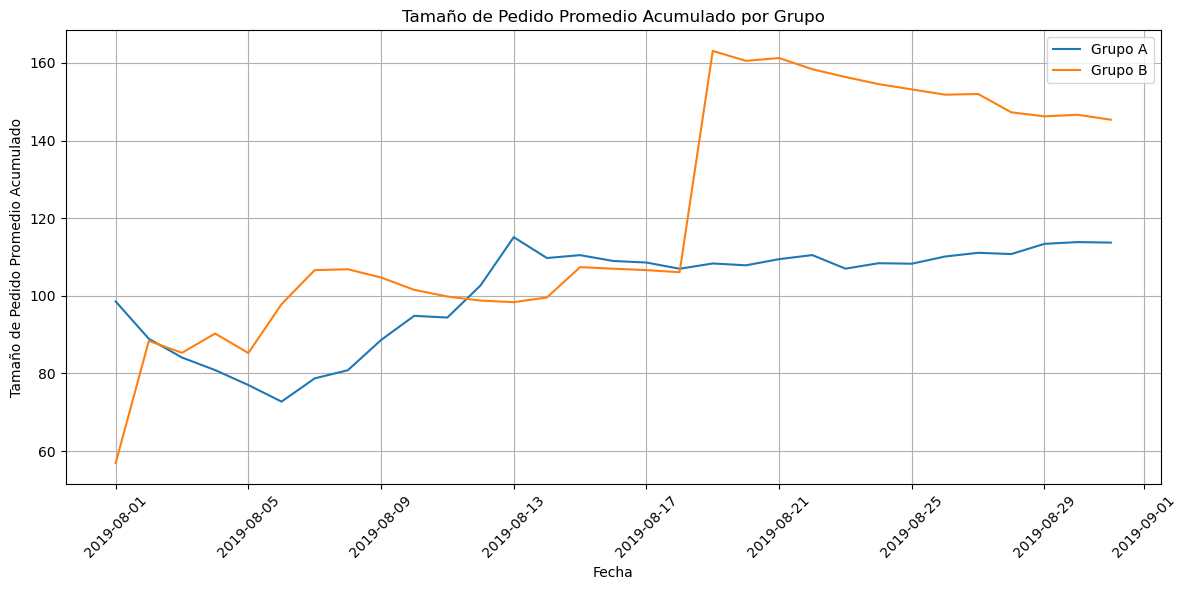

In [24]:
# Se calcula el tamaño de pedido promedio acumulado para el grupo A
cumulative_orders_a['avg_order_size_cumulative_a'] = cumulative_orders_a['revenue_cumulative_a'] / cumulative_orders_a['orders_cumulative_a']

# Se calcula el tamaño de pedido promedio acumulado para el grupo B
cumulative_orders_b['avg_order_size_cumulative_b'] = cumulative_orders_b['revenue_cumulative_b'] / cumulative_orders_b['orders_cumulative_b']

# Se combina los datos acumulados para el tamaño promedio de pedido
cumulative_data = cumulative_data.merge(cumulative_orders_a[['date', 'avg_order_size_cumulative_a']], on='date', how='left')
cumulative_data = cumulative_data.merge(cumulative_orders_b[['date', 'avg_order_size_cumulative_b']], on='date', how='left')

# Se rellena los valores nulos para mantener la acumulación
cumulative_data['avg_order_size_cumulative_a'] = cumulative_data['avg_order_size_cumulative_a'].ffill()
cumulative_data['avg_order_size_cumulative_b'] = cumulative_data['avg_order_size_cumulative_b'].ffill()

# Se grafica el tamaño de pedido promedio acumulado por grupo
plt.figure(figsize=(12, 6))
plt.plot(cumulative_data['date'], cumulative_data['avg_order_size_cumulative_a'], label='Grupo A')
plt.plot(cumulative_data['date'], cumulative_data['avg_order_size_cumulative_b'], label='Grupo B')
plt.title('Tamaño de Pedido Promedio Acumulado por Grupo')
plt.xlabel('Fecha')
plt.ylabel('Tamaño de Pedido Promedio Acumulado')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2.1 Conclusiones del ejercicio 2

Al momento de revisar los datos se alcanzan a percibir lo siguiente:

* En primera instancia, al comienzo de la prueba ambos grupos tuvieron un promedio de pedidos similares, sin embargo, con forme avanzo el tiempo el grupo A presento una ligera tendencia bajista con respecto a grupo B, pasado los dias esta tendencia bajista se revirtio sin poder superar a B, por su parte, el grupo B sostuvo una tendencia alcista, al principio con estandares conservadores, con forme pasaron los días la tendencia alcista se vio mucho mas pronunciada.

* En segunda instancia, se pudo confirmar que, entre los días 17 de Agosto a 20 de Agosto hubo un aumento considerable en el tamaño de los pedidos promedios, del grupo B, esto refuerza la teoria de un incremento considerables de pedidos de alto valor durante este lapso de días, posterior a este incremento, el grupo B tuvo un decrecimiento paulatino con forme pasaron los días, sin tener una perdida significativa, conservando su tendencia.

Al apreciar esta tendencia del grupo B, podemos aprecias que hay pedidos muy grandes que estan sesgando el promedio, lo que nos indica que se tiene que llevar a cabo un proceso para filtrar y remover los valores atipicos que este llegando a afecar la prueba.

## 4.3 Ejercicio 3

Instrucción: Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A. Haz conclusiones y conjeturas.

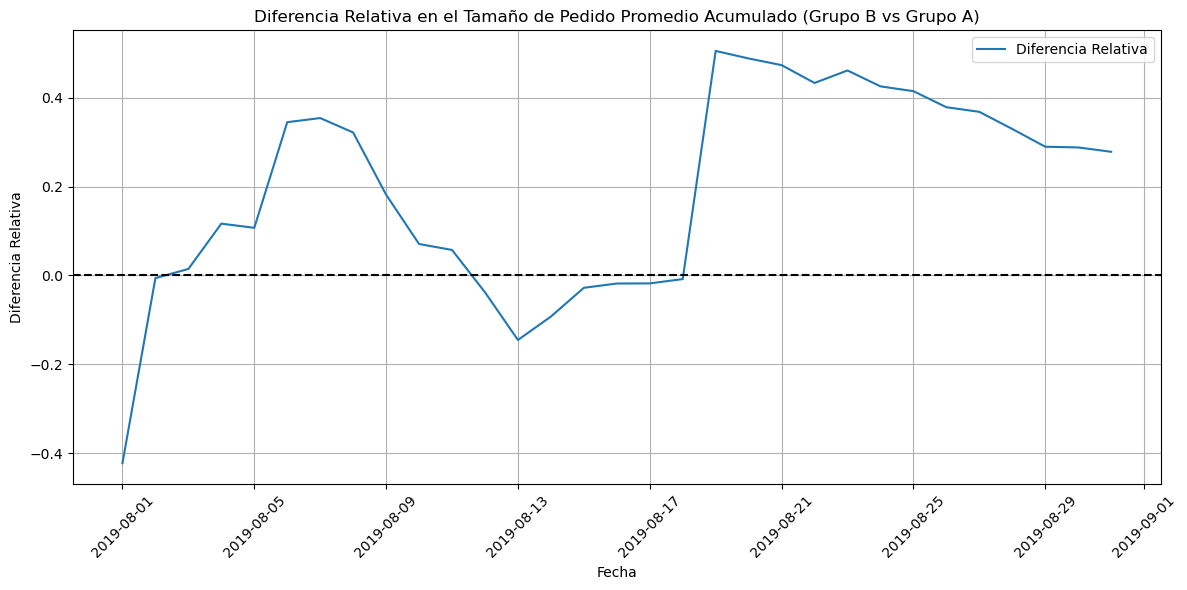

In [25]:
# Se calcula la diferencia relativa en el tamaño de pedido promedio acumulado
cumulative_data['relative_avg_order_size_diff'] = (cumulative_data['avg_order_size_cumulative_b'] / cumulative_data['avg_order_size_cumulative_a']) - 1

# Se traza un gráfico de diferencia relativa para los tamaños de compra promedio
plt.figure(figsize=(12, 6))
plt.plot(cumulative_data['date'], cumulative_data['relative_avg_order_size_diff'])
plt.title('Diferencia Relativa en el Tamaño de Pedido Promedio Acumulado (Grupo B vs Grupo A)')
plt.xlabel('Fecha')
plt.ylabel('Diferencia Relativa')
plt.axhline(y=0, color='black', linestyle='--')
plt.legend(['Diferencia Relativa'])
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.3.1 Conclusiones del ejercicio 3

Al momento de analizar los datos mis conclusiones son las siguientes:

* Al inicio de la prueba, la diferencia relativa fluctuó significativamente, lo cual es normal en las primeras etapas de un test A/B debido al bajo volumen de datos.
* Alrededor del 17 al 20 de agosto, el Grupo B experimentó un pico muy pronunciado en su tamaño de pedido promedio en comparación con el Grupo A. Esta es la misma fecha donde observamos anomalías tanto en los ingresos acumulados como en el tamaño promedio de pedido acumulado del Grupo B.
* Después de este pico, la diferencia relativa para el Grupo B se mantiene consistentemente positiva, indicando que su tamaño de pedido promedio acumulado es mayor que el del Grupo A. Sin embargo, se observa una tendencia a la baja después del pico, lo que sugiere que la influencia de los pedidos anómalos está disminuyendo o que el rendimiento del Grupo B se está estabilizando.

En conclusión, en el presente grafico se puede apreciar que el grupo B tiene un mayor tamaño de pedidos cumulados que el grupo A, sin embargo, al percibir nuevamente la tendencía anomala en las mismas fechas, refuerza la precensía de pedidos anomales de alto valor.


## 4.4 Ejercicio 4

Instrucción: Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. Saca conclusiones y haz conjeturas.

[Se preparan los datos para el cálculo de la tasa de conversión]

In [26]:
# Se crea un DataFrame con las fechas únicas y los grupos
dates = orders_filtered['date'].unique().tolist()
dates.sort()

# Se agrupan los pedidos por fecha y grupo para obtener el número de pedidos y el ingreso
daily_orders_a = orders_filtered_a.groupby('date').agg({
    'transactionId': 'nunique',
    'revenue': 'sum'
}).reset_index()
daily_orders_a.columns = ['date', 'orders', 'revenue']
daily_orders_a['group'] = 'A'

daily_orders_b = orders_filtered_b.groupby('date').agg({
    'transactionId': 'nunique',
    'revenue': 'sum'
}).reset_index()
daily_orders_b.columns = ['date', 'orders', 'revenue']
daily_orders_b['group'] = 'B'

# Se combinan los pedidos diarios de ambos grupos
daily_orders = pd.concat([daily_orders_a, daily_orders_b], ignore_index=True)

# Se combinan los datos de visitas
daily_visits = visits.copy()

# Se crea un DataFrame con todos los días únicos y grupos para asegurar que todas las fechas estén presentes
full_dates_groups = pd.MultiIndex.from_product([dates, ['A', 'B']], names=['date', 'group']).to_frame(index=False)

# Se unen los datos diarios de pedidos y visitas
merged_data = full_dates_groups.merge(daily_orders, on=['date', 'group'], how='left').fillna(0)
merged_data = merged_data.merge(daily_visits, on=['date', 'group'], how='left').fillna(0)

# Se ordenan los datos por fecha y grupo
merged_data = merged_data.sort_values(by=['date', 'group'])

# Se calculan los valores acumulados
merged_data['cumulative_orders'] = merged_data.groupby('group')['orders'].cumsum()
merged_data['cumulative_revenue'] = merged_data.groupby('group')['revenue'].cumsum()
merged_data['cumulative_visits'] = merged_data.groupby('group')['visits'].cumsum()

# Se calcula la tasa de conversión acumulada
merged_data['conversion'] = merged_data['cumulative_orders'] / merged_data['cumulative_visits']

# Se visualizan los datos combinados y acumulados
print('Datos combinados y acumulados para el cálculo de la conversión:')

merged_data.info()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
merged_data.head(10)

Datos combinados y acumulados para el cálculo de la conversión:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   date                62 non-null     datetime64[ns]
 1   group               62 non-null     object        
 2   orders              62 non-null     int64         
 3   revenue             62 non-null     float64       
 4   visits              62 non-null     int64         
 5   cumulative_orders   62 non-null     int64         
 6   cumulative_revenue  62 non-null     float64       
 7   cumulative_visits   62 non-null     int64         
 8   conversion          62 non-null     float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(1)
memory usage: 4.5+ KB
 
 
---------------------------------------
 
 


,date,group,orders,revenue,visits,cumulative_orders,cumulative_revenue,cumulative_visits,conversion
0,2019-08-01,A,23,2266.6,719,23,2266.6,719,0.031989
1,2019-08-01,B,17,967.2,713,17,967.2,713,0.023843
2,2019-08-02,A,19,1468.3,619,42,3734.9,1338,0.031390
3,2019-08-02,B,23,2568.1,581,40,3535.3,1294,0.030912
4,2019-08-03,A,24,1815.2,507,66,5550.1,1845,0.035772
5,2019-08-03,B,14,1071.6,509,54,4606.9,1803,0.029950
6,2019-08-04,A,11,675.5,717,77,6225.6,2562,0.030055
7,2019-08-04,B,14,1531.6,770,68,6138.5,2573,0.026428
8,2019-08-05,A,22,1398.0,756,99,7623.6,3318,0.029837
9,2019-08-05,B,21,1449.3,707,89,7587.8,3280,0.027134


[Se gráfica la tasa de conversión diaria acumulada por grupo]

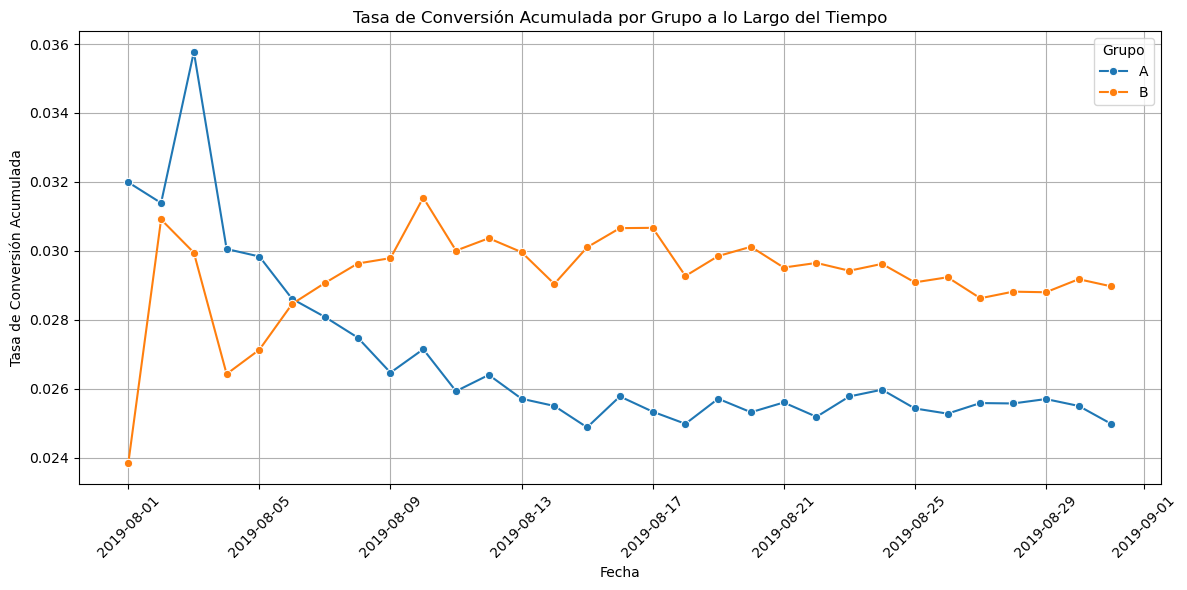

In [27]:
# Se grafica la tasa de conversión acumulada por grupo
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=merged_data,
    x='date',
    y='conversion',
    hue='group',
    marker='o'
)

plt.title('Tasa de Conversión Acumulada por Grupo a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Tasa de Conversión Acumulada')
plt.legend(title='Grupo')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.4.1 Conclusiones del ejercicio 4

Al momento de analizar los datos, se puede percibir lo siguiente:

* En primera instancia, se puede percibir que al inicio del test, las tasas de conversión de ambos grupos fluctuaron bastante, sin embargo, es común al comienso de cada prueba debido a la falta de datos en las etapas inciales.
* En segunda instancia, se ve una notoría diferencía entre las tasas de ambos grupos. Llegando el punto en el que el grupo B supero al grupo A.
* En tercera instancia, el grupo B tuvo una notable consitencia al momento de estabiliarse a un nivel mas alto, en comparación del grupo A.

En conclusiones generales, el grupo B muestra una tasa de conversión superior, los usuarios de este grupo mostraron una tendencia positiva. Como conjetura, es conveniente replicar la estrategía del grupo B.

## 4.5 Ejercicio 5

Instrucción: Traza un gráfico de dispersión del número de pedidos por usuario. Haz conclusiones y conjeturas.

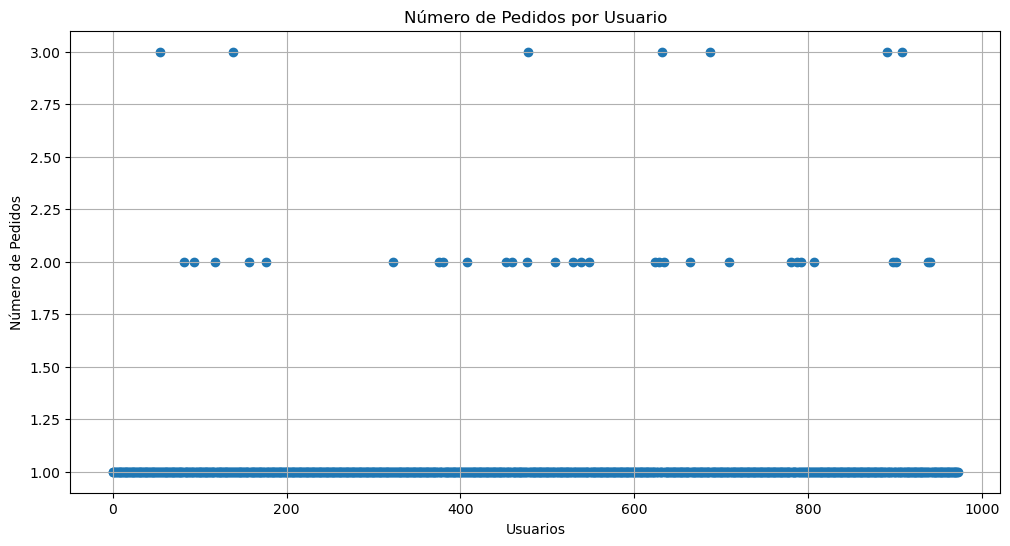

In [28]:
# Se calcula el número de pedidos por usuario
orders_by_users = orders_filtered.groupby('visitorId')['transactionId'].nunique().reset_index()
orders_by_users.columns = ['visitorId', 'orders']

# Se traza un gráfico de dispersión del número de pedidos por usuario
x_values = pd.Series(range(0, len(orders_by_users)))
plt.figure(figsize=(12, 6))
plt.scatter(x_values, orders_by_users['orders'])
plt.title('Número de Pedidos por Usuario')
plt.xlabel('Usuarios')
plt.ylabel('Número de Pedidos')
plt.grid(True)
plt.show()

### 4.5.1 Conclusiones del ejercicio 5

Al analizar el grafico de dispersión podeos tener una confirmación mas clara sobre los pedidos anomalos, estos pueden estar afectando los resultados obtenidos hasta el momento. Por tal motivo se tiene que realizar el analisis de los datos descartando los datos aomalos.

## 4.6 Ejercicio 6

Instrucción: Calcula los percentiles 95 y 99 del número de pedidos por usuario. Define el punto en el cual un punto de datos se convierte en una anomalía.

In [29]:
# Se procede a crear una variable que contenga el calculo de los percentiles 95 y otra donde tenga el 99 del numero de pedidos por usuarios:

percentile_95 = orders_by_users['orders'].quantile(0.95)
percentile_99 = orders_by_users['orders'].quantile(0.99)

# Se procede a imprimirlos por separado:

print('Los percentiles 95 y 99 son los siguientes:')
print('------------------------')
print('El percentil 95 es:', percentile_95)
print(' ')
print('---------------------------------------')
print(' ')
print('El percentil 99 es:', percentile_99)

Los percentiles 95 y 99 son los siguientes:
------------------------
El percentil 95 es: 1.0
 
---------------------------------------
 
El percentil 99 es: 2.0


### 4.6.1 Conclusiones del ejercicio 6

Al realizar el calculo de los percentiles 95 y 99 del numero de pedidos por usuario, nos podemos dar cuenta que los datos anomalos surgen a partir de la siguiente manera:

* **Percentil 95%:** `1`
* **Percentil 99%:** `2`

Dandonos como resultado el considerarse una norma todos aquellos usuarios que piden solo 1 vez, considerando anomalos todos aquellos que piden mas de 2 veces

Por lo tanto, sería razonable fijar un umbral de 2 o más órdenes por usuario como límite superior para un comportamiento anormal y utilizarlo para filtrar cualquier anomalía

## 4.7 Ejercicio 7

Instrucción: Traza un gráfico de dispersión de los precios de los pedidos. Haz conclusiones y conjeturas.

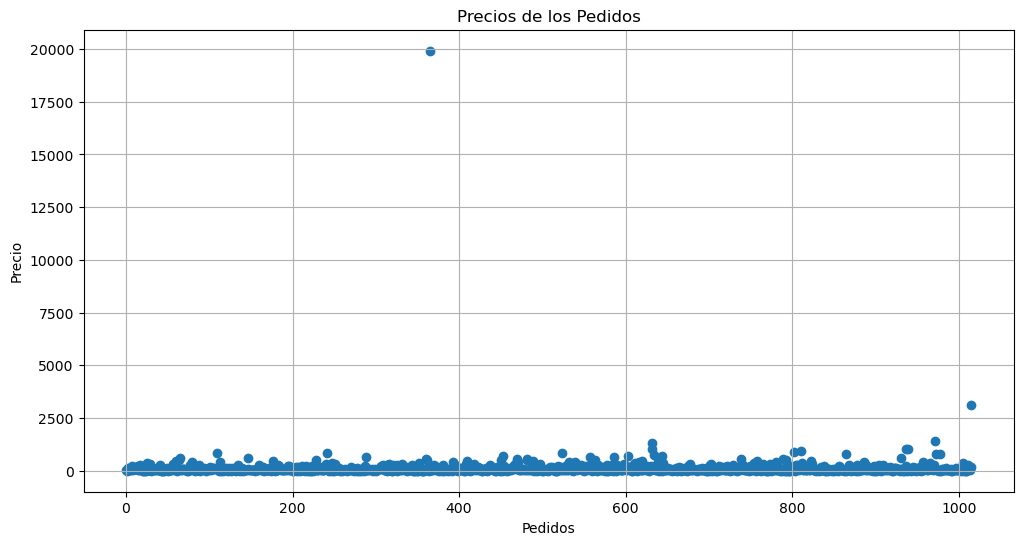

In [30]:
# Se procedea crear un grafico de dispersión de los precios de los pedidos

x_values = pd.Series(range(0, len(orders_filtered)))
plt.figure(figsize=(12, 6))
plt.scatter(x_values, orders_filtered['revenue'])
plt.title('Precios de los Pedidos')
plt.xlabel('Pedidos')
plt.ylabel('Precio')
plt.grid(True)
plt.show()


### 4.7.1 Conlusiones del ejercicio 7

Al revisar el grafico de dispersión de los precios de los pedidos, se puede llegar a la conclusión de que la gran mayoría de los pedidos tienen un precio relativamente bajo. La precencia de algunos pedidos con valores de ingresos extremadamente altos afectarán significativamente los resultados de la prueba A/B, esto es, si no se llegan a manejar adecuadamente puede llegar a alteras las metricas promedio.

Es por ello que es fundamental identificar y tratar estos valores atipicos antes de realizar el análisis mas profundos.

## 4.8 Ejercicio 8

Instrucción: Calcula los percentiles 95 y 99 de los precios de los pedidos. Define el punto en el cual un punto de datos se convierte en una anomalía.

In [31]:
# Se procede a crear 2 variables una con los percentiles 95 y la otra con los 99 de los precios de los pedidos

percentile_revenue_95 = orders_filtered['revenue'].quantile(0.95)
percentile_revenue_99 = orders_filtered['revenue'].quantile(0.99)

# # Se procede a imprimirlos por separado:

print('Los percentiles 95 y 99 son los siguientes:')
print('------------------------')
print('El percentil 95 es:', percentile_revenue_95)
print(' ')
print('---------------------------------------')
print(' ')
print('El percentil 99 es:', percentile_revenue_99)

Los percentiles 95 y 99 son los siguientes:
------------------------
El percentil 95 es: 414.275
 
---------------------------------------
 
El percentil 99 es: 830.3


### 4.8.1 Conclusiones del ejercicio 8

Al realizar el calculo de los percentiles 95 y 99 de los precios de los pedidos, nos podemos dar cuenta que los datos anomalos surgen a partir de la siguiente manera:

*   **Percentil 95:** `414.275`
*   **Percentil 99:** `830.3`

Esto significa que el 95% de los pedidos tienen un precio inferior o igual a `414.275`, y el 99% de los pedidos tienen un precio inferior o igual a `830.3`.

Por lo tanto se podría definir a todos aquellos pedidos superiores a `830.3` como "excepsionalmente grandes", fijando como umbal a estos como datos anomalos para evitar sesgar la prueba y el analisis de los datos

## 4.9 Ejercicio 9

Instrucción: Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

[Se procedera a trabajar con los datos en bruto del DF "orders" antes de haber realizdo el trabajo de filtrarlos]

In [32]:
# Se realiza una copia del DF original "orders" para trabajar con este.

orders_copy = orders.copy()

# Se realiza lo mismo con el DF "visits"

visits_copy = visits.copy()

# Se procede a crear las variables 'ordersByUsersA' y 'ordersByUsersB' para almacenar las columnas ['userId', 'orders']. Para los usuarios con al menos un pedido

ordersByUsersA = orders_copy[orders_copy['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersA.columns = ['visitorId', 'orders']

ordersByUsersB = orders_copy[orders_copy['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersB.columns = ['visitorId', 'orders']


# Se proede a crear las variables 'sampleA' y 'sampleB' con usuarios de diferentes grupos y números de pedidos correspondientes.

sampleA = pd.concat([ordersByUsersA['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA['orders'])), name='orders')],axis=0)
sampleB = pd.concat([ordersByUsersB['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB['orders'])), name='orders')],axis=0)

# Se procede a imprimir la significancia estadística y la ganancia relativa de conversión
print('P-valor de la diferencia en la conversión (datos en bruto):')
print("{0:.3f}".format(stats.mannwhitneyu(sampleA, sampleB)[1]))
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
print('Ganancia relativa de la conversión (Grupo B vs Grupo A, datos en bruto):')
print("{0:.3f}".format(sampleB.mean()/sampleA.mean()-1))

P-valor de la diferencia en la conversión (datos en bruto):
0.017
 
 
---------------------------------------
 
 
Ganancia relativa de la conversión (Grupo B vs Grupo A, datos en bruto):
0.138


### 4.9.1 Conclusiones del ejercicio 9

Al generar la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto, se pudieron obtener los siugientes datos:

* Diferencia en la conversión: `0.17%`
* Ganancia relativa: `13.8%`

Por tal motivo podemos determinar que la diferencia observada es estadisticamente significativa, por lo tanto, si se analiza unicamente los datos en bruto, se puede determinar que el cambio realizado en los parametros del grupo B si represento un cambio real en el comportamiento de los pedidos.

Por otra parte, en cuanto a la gancia total, podemos observar que esta tuvo un porcentaje positivo, por lo tanto, se puede apreciar que los cambios realizados en el grupo B generaron un ingreso positivo.

## 4.10 Ejercicio 10

Instucción: Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

In [33]:
# Se procede a imprimir la significancia estadística y la ganancia relativa de conversión
print('P-valor de la diferencia en la conversión (datos en bruto):')
print('{0:.3f}'.format(stats.mannwhitneyu(orders_copy[orders_copy['group']=='A']['revenue'], orders_copy[orders_copy['group']=='B']['revenue'])[1]))
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
print('Ganancia relativa del tamaño promedio de pedido (Grupo B vs Grupo A, datos en bruto):')
print('{0:.3f}'.format(orders_copy[orders_copy['group']=='B']['revenue'].mean()/orders_copy[orders_copy['group']=='A']['revenue'].mean()-1))

P-valor de la diferencia en la conversión (datos en bruto):
0.692
 
 
---------------------------------------
 
 
Ganancia relativa del tamaño promedio de pedido (Grupo B vs Grupo A, datos en bruto):
0.252


### 4.10.1 Conclusiones del ejercicio 10

Al generar la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto, se pudieron obtener los siguientes datos:

* Diferencia en la conversión: `69.2%`
* Ganancia relativa: `25.2%`

Por tal motivo podemos apreciar con los resultados de la significancia que los datos no son concluyentes, hay valores que provocan mucho ruido en la visualización de estos, por tal motivo, se tendrían que repetir con los datos filtrados, como lo pudimos apreciar a lo largo del proyecto, hay datos anomalos causando ruido en los pedidos, generando así que no se pueda continuar con la base de datos sin filtrar los datos anomalos.

En cuanto a la ganancía relativa, si bien hay un porcentaje relevante en cuanto a la utilidad obtenida, al estar fuera de proporción la diferencía en la conversión, los datos obtenidos no son fiables.

## 4.11 Ejercicio 11

Instrucción: Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.

In [34]:
# Se procede a definir los umbrales para anomalías (percentiles 99)
# Obtenidos del ejercicio 4.6 (pedidos por usuario) y 4.8 (precio de pedidos)
orders_by_users = orders_filtered.groupby('visitorId')['transactionId'].nunique().reset_index()
orders_by_users.columns = ['visitorId', 'orders']

percentiles_orders = orders_by_users['orders'].quantile(0.99)
percentiles_revenue = orders_filtered['revenue'].quantile(0.99)

print(f"Umbral de pedidos por usuario (percentil 99): {percentiles_orders}")
print(f"Umbral de ingresos por pedido (percentil 99): {percentiles_revenue}")

# Se identifican usuarios y pedidos anómalos
# Los usuarios con más pedidos que el percentil 99
anomalous_users = orders_by_users[orders_by_users['orders'] > percentiles_orders]['visitorId'].tolist()

# Pedidos con revenue mayor que el percentil 99
anomalous_revenue_orders = orders_filtered[orders_filtered['revenue'] > percentiles_revenue]['transactionId'].tolist()
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
print(f"\nNúmero de usuarios anómalos por cantidad de pedidos: {len(anomalous_users)}")
print(f"Número de pedidos anómalos por valor de ingresos: {len(anomalous_revenue_orders)}")

Umbral de pedidos por usuario (percentil 99): 2.0
Umbral de ingresos por pedido (percentil 99): 830.3
 
 
---------------------------------------
 
 

Número de usuarios anómalos por cantidad de pedidos: 7
Número de pedidos anómalos por valor de ingresos: 9


In [35]:
# Se filtra el DataFrame original 'orders_filtered' para eliminar anomalías
# Se eliminan los usuarios anómalos y pedidos con ingresos anómalos
orders_cleaned = orders_filtered[~orders_filtered['visitorId'].isin(anomalous_users)]
orders_cleaned = orders_cleaned[~orders_cleaned['transactionId'].isin(anomalous_revenue_orders)]

print(f"Número total de entradas en 'orders_filtered': {orders_filtered.shape[0]}")
print(f"Número total de entradas en 'orders_cleaned' (después de filtrar anomalías): {orders_cleaned.shape[0]}")

print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')

orders_cleaned.head()

Número total de entradas en 'orders_filtered': 1016
Número total de entradas en 'orders_cleaned' (después de filtrar anomalías): 986
 
 
---------------------------------------
 
 


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B
5,182168103,935554773,2019-08-15,35.0,B


In [36]:
# Se procede a crear las variables 'ordersByUsersA_filtered' y 'ordersByUsersB_filtered' para almacenar las columnas ['userId', 'orders']. Para los usuarios con al menos un pedido

ordersByUsersA_filtered = orders_cleaned[orders_cleaned['group']=='A'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersA_filtered.columns = ['visitorId', 'orders']

ordersByUsersB_filtered = orders_cleaned[orders_cleaned['group']=='B'].groupby('visitorId', as_index=False).agg({'transactionId' : pd.Series.nunique})
ordersByUsersB_filtered.columns = ['visitorId', 'orders']


# Se proede a crear las variables 'sampleA_filtered' y 'sampleB_filtered' con usuarios de diferentes grupos y números de pedidos correspondientes.

sampleA_filtered = pd.concat([ordersByUsersA_filtered['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='A']['visits'].sum() - len(ordersByUsersA_filtered['orders'])), name='orders')],axis=0)
sampleB_filtered = pd.concat([ordersByUsersB_filtered['orders'],pd.Series(0, index=np.arange(visits[visits['group']=='B']['visits'].sum() - len(ordersByUsersB_filtered['orders'])), name='orders')],axis=0)

# Se procede a imprimir la significancia estadística y la ganancia relativa de conversión
print('P-valor de la diferencia en la conversión (datos en bruto):')
print("{0:.3f}".format(stats.mannwhitneyu(sampleA_filtered, sampleB_filtered)[1]))
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
print('Ganancia relativa de la conversión (Grupo B vs Grupo A, datos en bruto):')
print("{0:.3f}".format(sampleB_filtered.mean()/sampleA_filtered.mean()-1))

P-valor de la diferencia en la conversión (datos en bruto):
0.007
 
 
---------------------------------------
 
 
Ganancia relativa de la conversión (Grupo B vs Grupo A, datos en bruto):
0.189


### 4.11.1 Conclusiones del ejercicio 11

Al generar la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados, se pudieron obtener los siugientes datos:

* Diferencia en la conversión: `0.07%`
* Ganancia relativa: `18.9%`

Por tal motivo podemos determinar que la diferencia observada es estadisticamente significativa, por lo tanto, al analizar los datos filtrados, se puede determinar que el cambio realizado en los parametros del grupo B si represento un cambio real en el comportamiento de los pedidos.

Por otra parte, en cuanto a la gancia total, podemos observar que esta tuvo un porcentaje positivo, por lo cual, se puede apreciar que los cambios realizados en el grupo B generaron un ingreso positivo.

Llegando a la conclusión que el cambio realizado obtuvo resultados positivos.

## 4.12 Ejercicio 12

Instrucción: Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.

Ahora que tenemos el DataFrame `orders_cleaned`, podemos proceder a recalcular la significancia estadística de la diferencia en el tamaño promedio de pedido, tal como se solicita en el Ejercicio 4.12, pero utilizando estos datos filtrados. Esto nos dará una visión más precisa al haber eliminado el ruido de los valores atípicos.

In [37]:
# Se preparan los datos para los grupos A y B con los pedidos limpios
revenue_a_cleaned = orders_cleaned[orders_cleaned['group'] == 'A']['revenue']
revenue_b_cleaned = orders_cleaned[orders_cleaned['group'] == 'B']['revenue']

print('P-valor de la diferencia en el tamaño promedio de pedido (datos filtrados y limpios):')
print('{0:.3f}'.format(stats.mannwhitneyu(revenue_a_cleaned, revenue_b_cleaned)[1]))
print(' ')
print(' ')
print('---------------------------------------')
print(' ')
print(' ')
print('Ganancia relativa del tamaño promedio de pedido (Grupo B vs Grupo A, datos filtrados y limpios):')
print('{0:.3f}'.format(revenue_b_cleaned.mean() / revenue_a_cleaned.mean() - 1))

P-valor de la diferencia en el tamaño promedio de pedido (datos filtrados y limpios):
0.822
 
 
---------------------------------------
 
 
Ganancia relativa del tamaño promedio de pedido (Grupo B vs Grupo A, datos filtrados y limpios):
-0.032


### 4.12.1 Conclusiones del ejercicio 12

Al generar la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados, se pudieron obtener los siguientes datos:

* Diferencia en la conversión: `82.2%`
* Ganancia relativa: `-3.2%`

Lo que nos da a entender que no son concluyentes, despues de haber filtrado los datos nos hemos dado cuenta que la relación entre ganancias y el tamaño de pedidos entre ambos grupos no genera un cambio, por tal motivo, a pesar de haber filtrado y quitado los datos anomalos, se pudo apreciar que el tamaño de los pedidos entre ambos grupos no fue un diferenciador.

Ahora, con estos datos obtenidos no se puede tomar en cuena como fidedigno los resultados de la Ganancia Relativa.


## 4.13 Ejercicio 13

Instrucción: Toma una decisión basada en los resultados de la prueba. Las decisiones posibles son: 1. Parar la prueba, considerar a uno de los grupos como líder. 2. Parar la prueba, concluir que no hay diferencia entre los grupos. 3. Continuar la prueba.

Dir. (inserte el nombre del Director)

Director de analísis estrategico

Gran Tienda Online

Por medio del presente correo aprovecho para extenderle un cordial saludos, y así mismo para hacerle llegar mis conclusiones sobre el análisis de la prueba A/B.

Al realizar un análisis exahustivo de los resultados obtenidos de ambos grupos (A/B), se pudieron obtener los siguientes datos relevante:

* Desde el comienzo de la prueba se pudo apreciar una tendencía positiva en cuanto al tamaño de los pedidos, como de los ingresos obtenidos del Grupo "B", teniendo mejores resultados que los obtenidos por el Grupo "A".

* Hubo un incremento bastante amplio en los dias 18 al 20 de agosto del Grupo "B" sobre el Grupo "A", en un principio se creyo que este inremento y posterior mantenimiento de la tendencía de este grupo se debió a datos anomalos y ruido en la información recabada, sin embargo, al momento de análizar los datos sin ruido y sin anomalías, se pudo descubrir que, si bien, el incremento se podría considerar como "anomalo", este no tuvo relación directa con los resultados finales de la prueba.

* Al analizar los datos sin ruido y sin anomalias, se pudo apreciar que el grupo "B" siguio conservando su tendencía alcista, manteniendo una ligera baja al final del ultimo muestreo, por otra parte, el grupo "A" no obtuvo reslutados positivos y en la mayor parte del tiempo de la prueba siguio manteniendo su tendencía bajista.

Con base a las 3 opciones de escenarios a tomar, o mas bien, la elección de los escenarios, se consideraría oportuno continuar con la prueba 15 días mas.

La razón es la siguiente, si bien desde el principio se pudo apreciar que el Grupo "B" siempre se mantuvo como el Grupo dominante a lo largo de la prueba, hay que tomar en cuenta que el periodo de tiempo evaluado fue corto, sin mencionar que nos encontramos en periodo vacacional, por tal motivo los datos podrían estar sesgados por la variable de "temporalidad vacacional", al haber un factor externo fuera de nuestro control como lo son "las vacaciones de verano", esto pudo ser el causante de la variación abrupta de pedidos e ingresos obtenidos entre los días 18 al 20 de agosto, por tal motivo, se recomienda continur con la prueba de 15 días a un 1 mes más, de esta manera se podra percibir si la tendencía del Grupo "B" se sigue manteniendo como lider de la prueba, o en su defecto, si los resultados obtenidos positivos del principio fueron causados por la afluencía de gente buscando compras en periodo vacacional y regeso a clase de los estudiantes de todos los niveles.

Por mi parte sería todo, esperando que todo haya sido de su completo agrado, me despido, no sin antes quedar en pie y al orden al pendiente de sus comenatrios.

Saludos!!

ATT

Data Analyst SR.

Jose Alfredo Gonzalez Neri

# 5.0 Conclusiones finales

Dir. (inserte el nombre del Director)

Director de analísis estrategico

Gran Tienda Online

Por medio del presente correo aprovecho para extenderle un cordial saludos, y así mismo para hacerle llegar mis comentarios sobre la prioridad de hipotesis a probar enumerando las 3 mas viables hasta el momento y mis conclusiones sobre el análisis de la prueba A/B realizado recientemente.


Se utilizaron los frameworks ICE y RICE para poder tener un mejor panorama sobre la prioridad de hipótesis a probar, dandole importancía a aquellas que tuvieran un mayor alcance en el publico objetivo, una buena relación de esfuerzo aplicado y manteniendo un mayor margen de rentabilidad sobre los mismos.


Como pudimos apreciar en los puntos 3.1 y 3.2 del presente Notebook, el orden de las hipótesis cambia entre el ICE y el RICE ¿A que se debe este cambio? Se debe principalmente al impacto y confianza vs esfuerzo de las hipótesis, si bien, al momento de correr ICE se puede tener una apreciación mas positivas entre unas hipótesis y otras, un factor a tomar en cuenta al momento de decidir cual hipótesis aterrizar es "el alcance de nuestro publico objetivo", es alli donde, si bien, en ICE algunas hipótesis estan mejor puntuadas, en cuanto a alcance no les fue de la misma manera ¿Eso es malo?, no realmente, mas bien es util para poder tener un orden de prioridad mas claro al momento de efectuar las hipótesis y de esta manera obtener una mayor rentabilidad.


Al analizar los datos anteriores, se recomienda dar como prioridad las hipótesis "7, 0 y 6", Ya que fueron las mas equilibradas y se podra tener un beneficio mayor a corto, mediano y largo plazo.

En cuanto a la prueba A/B. Al realizar un análisis exahustivo de los resultados obtenidos de ambos grupos A/B (los cuales se peden apreciar desde los puntos 4.1 al 4.12 en el presente Notebook), se pudieron obtener los siguientes datos relevante:

* Desde el comienzo de la prueba se pudo apreciar una tendencía positiva en cuanto al tamaño de los pedidos, como de los ingresos obtenidos del Grupo "B", teniendo mejores resultados que los obtenidos por el Grupo "A".

* Hubo un incremento bastante amplio en los dias 18 al 20 de agosto del Grupo "B" sobre el Grupo "A", en un principio se creyo que este inremento y posterior mantenimiento de la tendencía de este grupo se debió a datos anomalos y ruido en la información recabada, sin embargo, al momento de análizar los datos sin ruido y sin anomalías, se pudo descubrir que, si bien, el incremento se podría considerar como "anomalo", este no tuvo relación directa con los resultados finales de la prueba.

* Al analizar los datos sin ruido y sin anomalias, se pudo apreciar que el grupo "B" siguio conservando su tendencía alcista, manteniendo una ligera baja al final del ultimo muestreo, por otra parte, el grupo "A" no obtuvo reslutados positivos y en la mayor parte del tiempo de la prueba siguio manteniendo su tendencía bajista.

Con base a las 3 opciones de escenarios a tomar, o mas bien, la elección de los escenarios, se consideraría oportuno continuar con la prueba 15 días mas.

La razón es la siguiente, si bien desde el principio se pudo apreciar que el Grupo "B" siempre se mantuvo como el Grupo dominante a lo largo de la prueba, hay que tomar en cuenta que el periodo de tiempo evaluado fue corto, sin mencionar que nos encontramos en periodo vacacional, por tal motivo los datos podrían estar sesgados por la variable de "temporalidad vacacional", al haber un factor externo fuera de nuestro control como lo son "las vacaciones de verano", esto pudo ser el causante de la variación abrupta de pedidos e ingresos obtenidos entre los días 18 al 20 de agosto, por tal motivo, se recomienda continur con la prueba de 15 días a un 1 mes más, de esta manera se podra percibir si la tendencía del Grupo "B" se sigue manteniendo como lider de la prueba, o en su defecto, si los resultados obtenidos positivos del principio fueron causados por la afluencía de gente buscando compras en periodo vacacional y regeso a clase de los estudiantes de todos los niveles.

Por mi parte sería todo, esperando que todo haya sido de su completo agrado, me despido, no sin antes quedar en pie y al orden al pendiente de sus comenatrios.

Saludos!!

ATT

Data Analyst SR.

Jose Alfredo Gonzalez Neri